# Part-2: Image Classification

In [53]:
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import cv2
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("All imports successful!")

All imports successful!


In [2]:
train_dir = r'C:\Users\Nitro\Desktop\ai-deeplearning\fruits-360\Training'
test_dir = r'C:\Users\Nitro\Desktop\ai-deeplearning\fruits-360\Test'

In [3]:
# corrupt files detection
print("Checking for corrupt images...")

corrupt_files = []
total_images = 0

for fruit in os.listdir(train_dir):
    fruit_path = os.path.join(train_dir, fruit)
    if os.path.isdir(fruit_path):
        for img_file in os.listdir(fruit_path):
            if img_file.endswith(('.jpg', '.jpeg', '.png')):
                total_images += 1
                img_path = os.path.join(fruit_path, img_file)
                try:
                    img = cv2.imread(img_path)
                    if img is None:
                        corrupt_files.append(img_path)
                        print(f"Corrupt: {img_path}")
                except Exception as e:
                    corrupt_files.append(img_path)
                    print(f"Error loading {img_path}: {e}")

print(f"\nTotal images checked: {total_images}")
print(f"Corrupt files found: {len(corrupt_files)}")

if len(corrupt_files) > 0:
    print("\nWARNING: Found corrupt files!")
else:
    print("No corrupt files found! Dataset is clean.")

Checking for corrupt images...

Total images checked: 7635
Corrupt files found: 0
No corrupt files found! Dataset is clean.


In [4]:
IMG_HEIGHT = 100
IMG_WIDTH = 100
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
EPOCHS = 20
LEARNING_RATE = 0.001
SEED = 42

print(f"Image size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

Image size: 100x100
Batch size: 32
Epochs: 20
Learning rate: 0.001


In [5]:
# Create an empty list to hold our fruit names
classes = []

# Get everything inside the training folder
folder_contents = os.listdir(train_dir)

for item in folder_contents:
    # Build the full path so the computer knows where to look
    item_path = os.path.join(train_dir, item)

    # Only want folders (categories), not any files that might be in there
    if os.path.isdir(item_path):
        classes.append(item)

# Sort them A-Z 
classes.sort()

print(f"Success! Found {len(classes)} different types of fruit.")

Success! Found 15 different types of fruit.


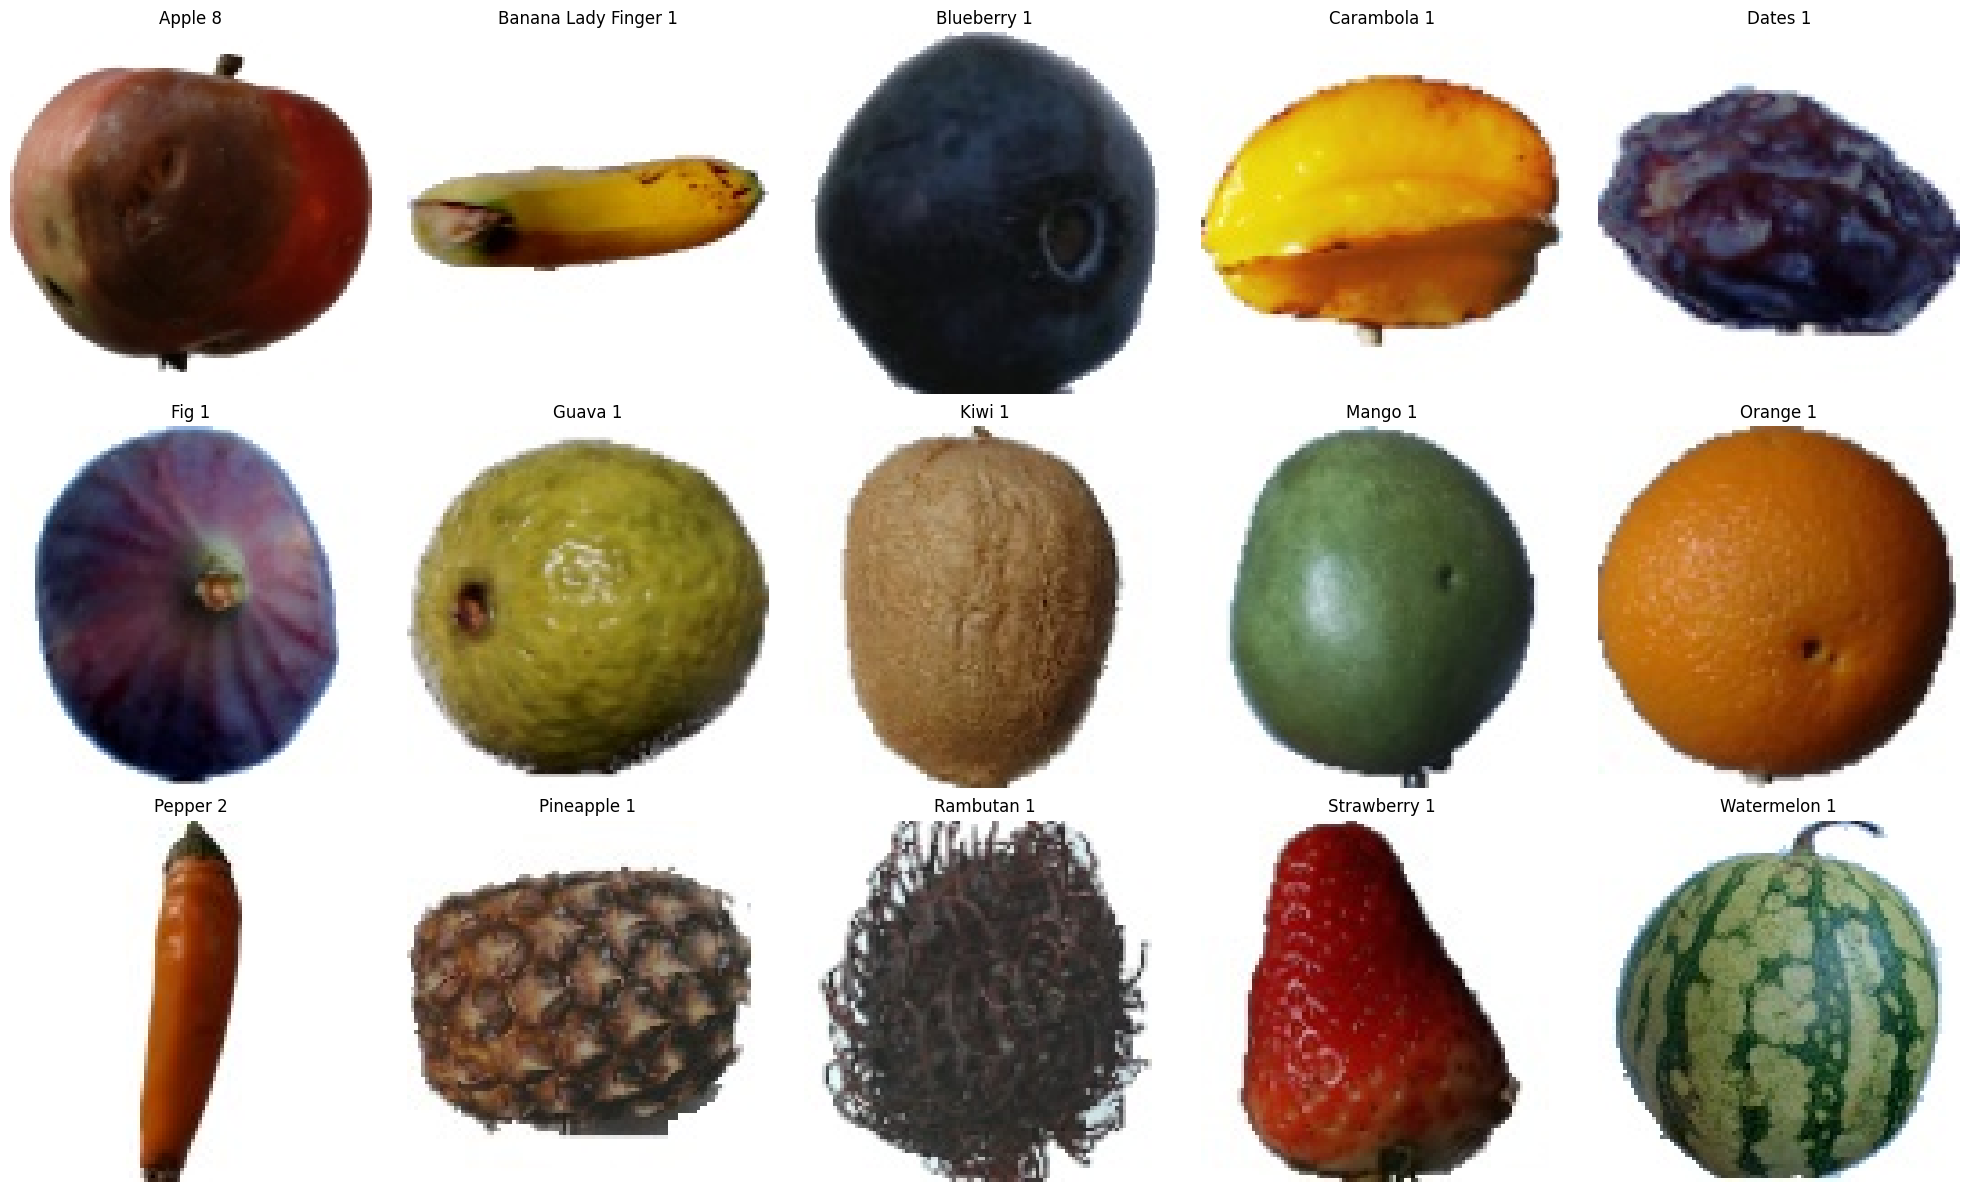

In [6]:
# Define the grid layout
images_per_row = 5
num_rows = (len(classes) + images_per_row - 1) // images_per_row  # Dynamic row calculation

# Create a large canvas 
plt.figure(figsize=(20, 4 * num_rows))

for i, fruit in enumerate(classes):
    folder_path = os.path.join(train_dir, fruit)

    # Get a list of all images in this fruit's folder
    all_images = os.listdir(folder_path)

    if all_images:
        # Pick one image and load it
        img_path = os.path.join(folder_path, random.choice(all_images))
        img_data = mpimg.imread(img_path)

        # 'i + 1' tells matplotlib which "slot" in the grid to use
        plt.subplot(num_rows, images_per_row, i + 1)
        plt.imshow(img_data)

        # Clean up the look
        plt.title(fruit, fontsize=12)
        plt.axis('off')

# Automatically fix spacing so titles don't overlap images
plt.tight_layout()
plt.show()

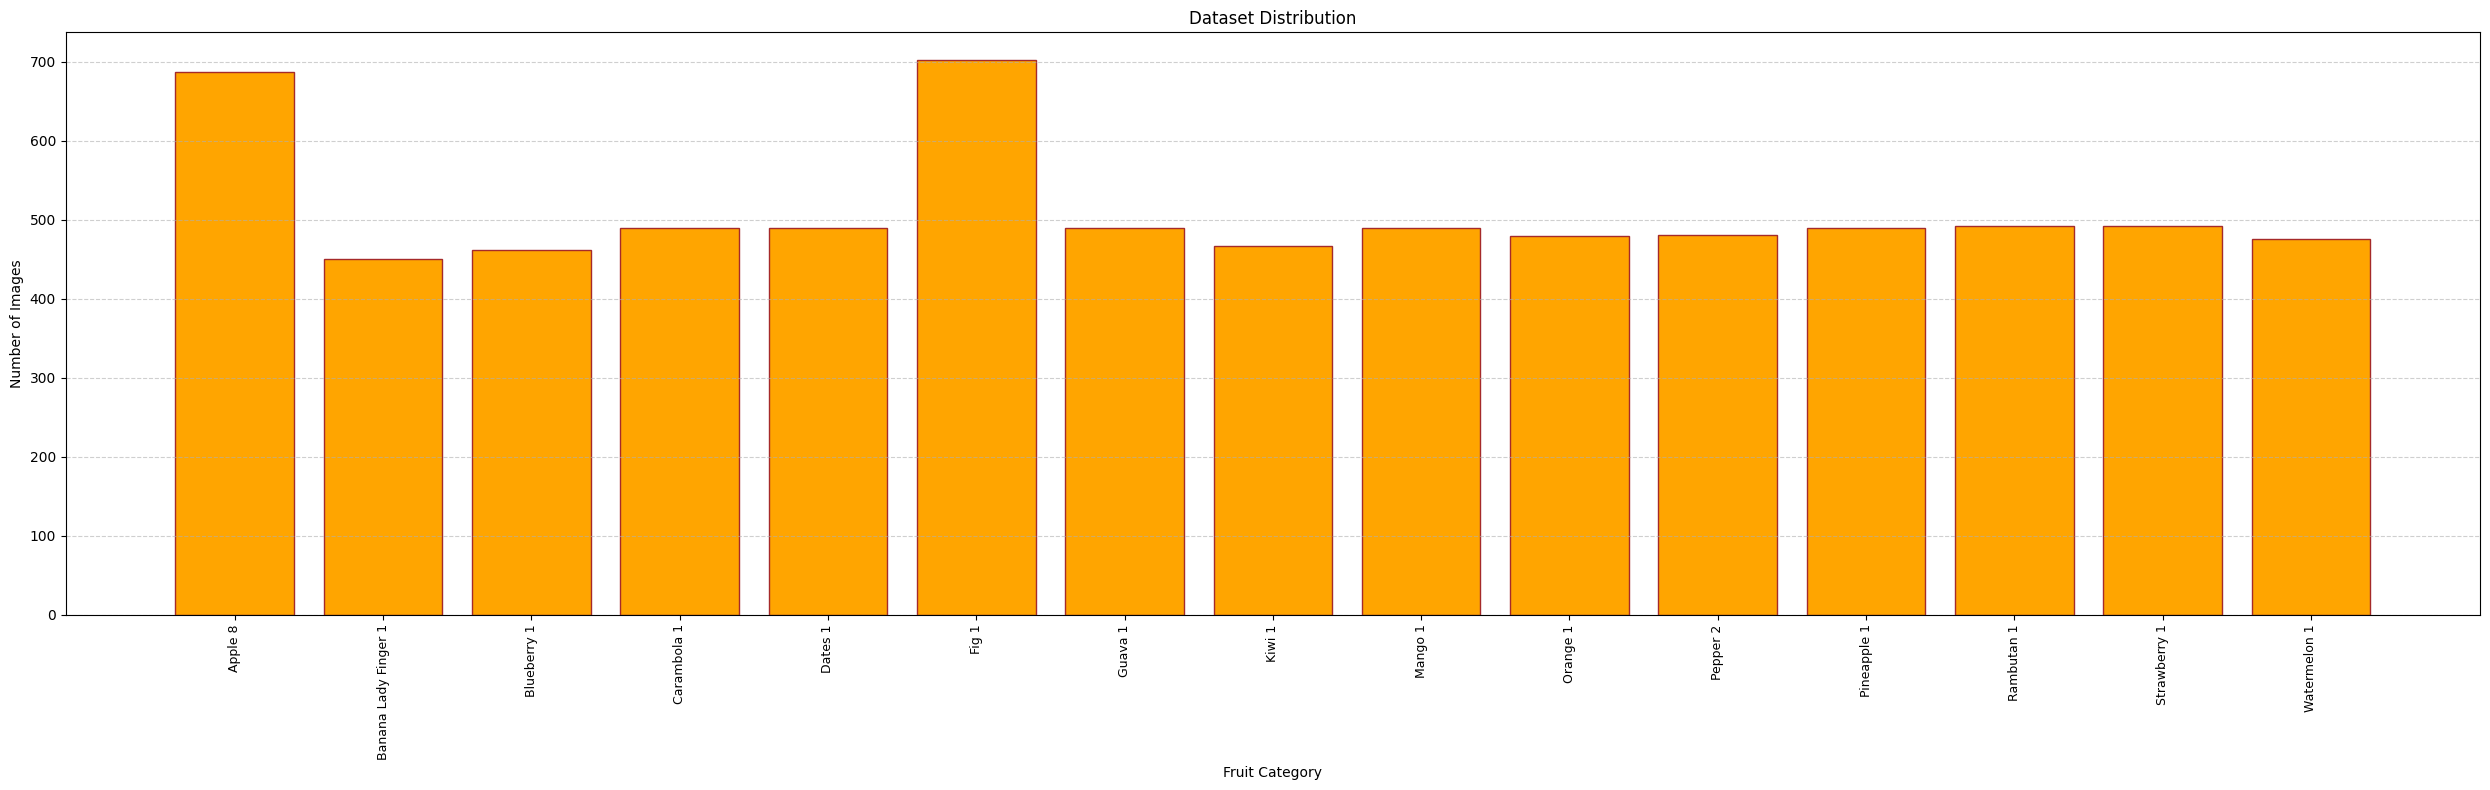

In [7]:
class_names = []
image_counts = []

for item in os.listdir(train_dir):
    item_path = os.path.join(train_dir, item)
    if os.path.isdir(item_path):
        class_names.append(item)
        image_counts.append(len(os.listdir(item_path)))

# Sort both lists together using a manual approach
paired = []
for i in range(len(class_names)):
    paired.append((class_names[i], image_counts[i]))

paired.sort()

# Create new sorted lists
sorted_names = []
sorted_counts = []
for name, count in paired:
    sorted_names.append(name)
    sorted_counts.append(count)

# visualise

plt.figure(figsize=(25, 8))
plt.bar(class_names, image_counts, color='orange', edgecolor='brown')
plt.xticks(rotation=90, fontsize=9)
plt.xlabel('Fruit Category')
plt.ylabel('Number of Images')
plt.title('Dataset Distribution')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [8]:
def simple_change_bg(img):
    """Simple background color change using threshold"""
    # Convert to grayscale for simple threshold
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Simple threshold - bright areas become background
    _, mask = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    
    # Random background color
    bg_color = np.random.randint(0, 256, 3, dtype=np.uint8)
    
    # Apply background color
    result = img.copy()
    result[mask > 0] = bg_color
    
    return result

In [9]:
# Cell 7: Balance dataset using simple background change
DATASET_PATH = train_dir
TARGET_COUNT = 1000
OUTPUT_SUFFIX = '_aug'

fruit_classes = sorted([d for d in os.listdir(DATASET_PATH) 
                        if os.path.isdir(os.path.join(DATASET_PATH, d))])

print(f"Found {len(fruit_classes)} fruit classes\n")

for fruit in fruit_classes:
    class_dir = os.path.join(DATASET_PATH, fruit)
    
    # Get original images (not augmented)
    existing = [f for f in os.listdir(class_dir) 
                if f.lower().endswith(('.jpg', '.jpeg', '.png')) 
                and OUTPUT_SUFFIX not in f]
    current = len(existing)
    need = max(0, TARGET_COUNT - current)
    
    print(f"[{fruit}]  existing: {current}  →  need: {need}")
    
    if need == 0:
        print(f"  Already at {TARGET_COUNT}, skipping.\n")
        continue
    
    for i in range(need):
        # Cycle through existing images as sources
        src_name = existing[i % len(existing)]
        src_path = os.path.join(class_dir, src_name)
        
        img = cv2.imread(src_path)
        if img is None:
            continue
        
        # Apply simple background change
        aug = simple_change_bg(img)  # chnage bg function
        
        base, ext = os.path.splitext(src_name)
        save_path = os.path.join(class_dir, f"{base}{OUTPUT_SUFFIX}_{i:04d}{ext}")
        cv2.imwrite(save_path, aug)
        
        if (i + 1) % 200 == 0:
            print(f"  Generated {i+1}/{need} images")
    
    print(f"  Done with {fruit}\n")

print("Dataset balancing complete!\n")

Found 15 fruit classes

[Apple 8]  existing: 687  →  need: 313
  Generated 200/313 images
  Done with Apple 8

[Banana Lady Finger 1]  existing: 450  →  need: 550
  Generated 200/550 images
  Generated 400/550 images
  Done with Banana Lady Finger 1

[Blueberry 1]  existing: 462  →  need: 538
  Generated 200/538 images
  Generated 400/538 images
  Done with Blueberry 1

[Carambola 1]  existing: 490  →  need: 510
  Generated 200/510 images
  Generated 400/510 images
  Done with Carambola 1

[Dates 1]  existing: 490  →  need: 510
  Generated 200/510 images
  Generated 400/510 images
  Done with Dates 1

[Fig 1]  existing: 702  →  need: 298
  Generated 200/298 images
  Done with Fig 1

[Guava 1]  existing: 490  →  need: 510
  Generated 200/510 images
  Generated 400/510 images
  Done with Guava 1

[Kiwi 1]  existing: 466  →  need: 534
  Generated 200/534 images
  Generated 400/534 images
  Done with Kiwi 1

[Mango 1]  existing: 490  →  need: 510
  Generated 200/510 images
  Generated 400/

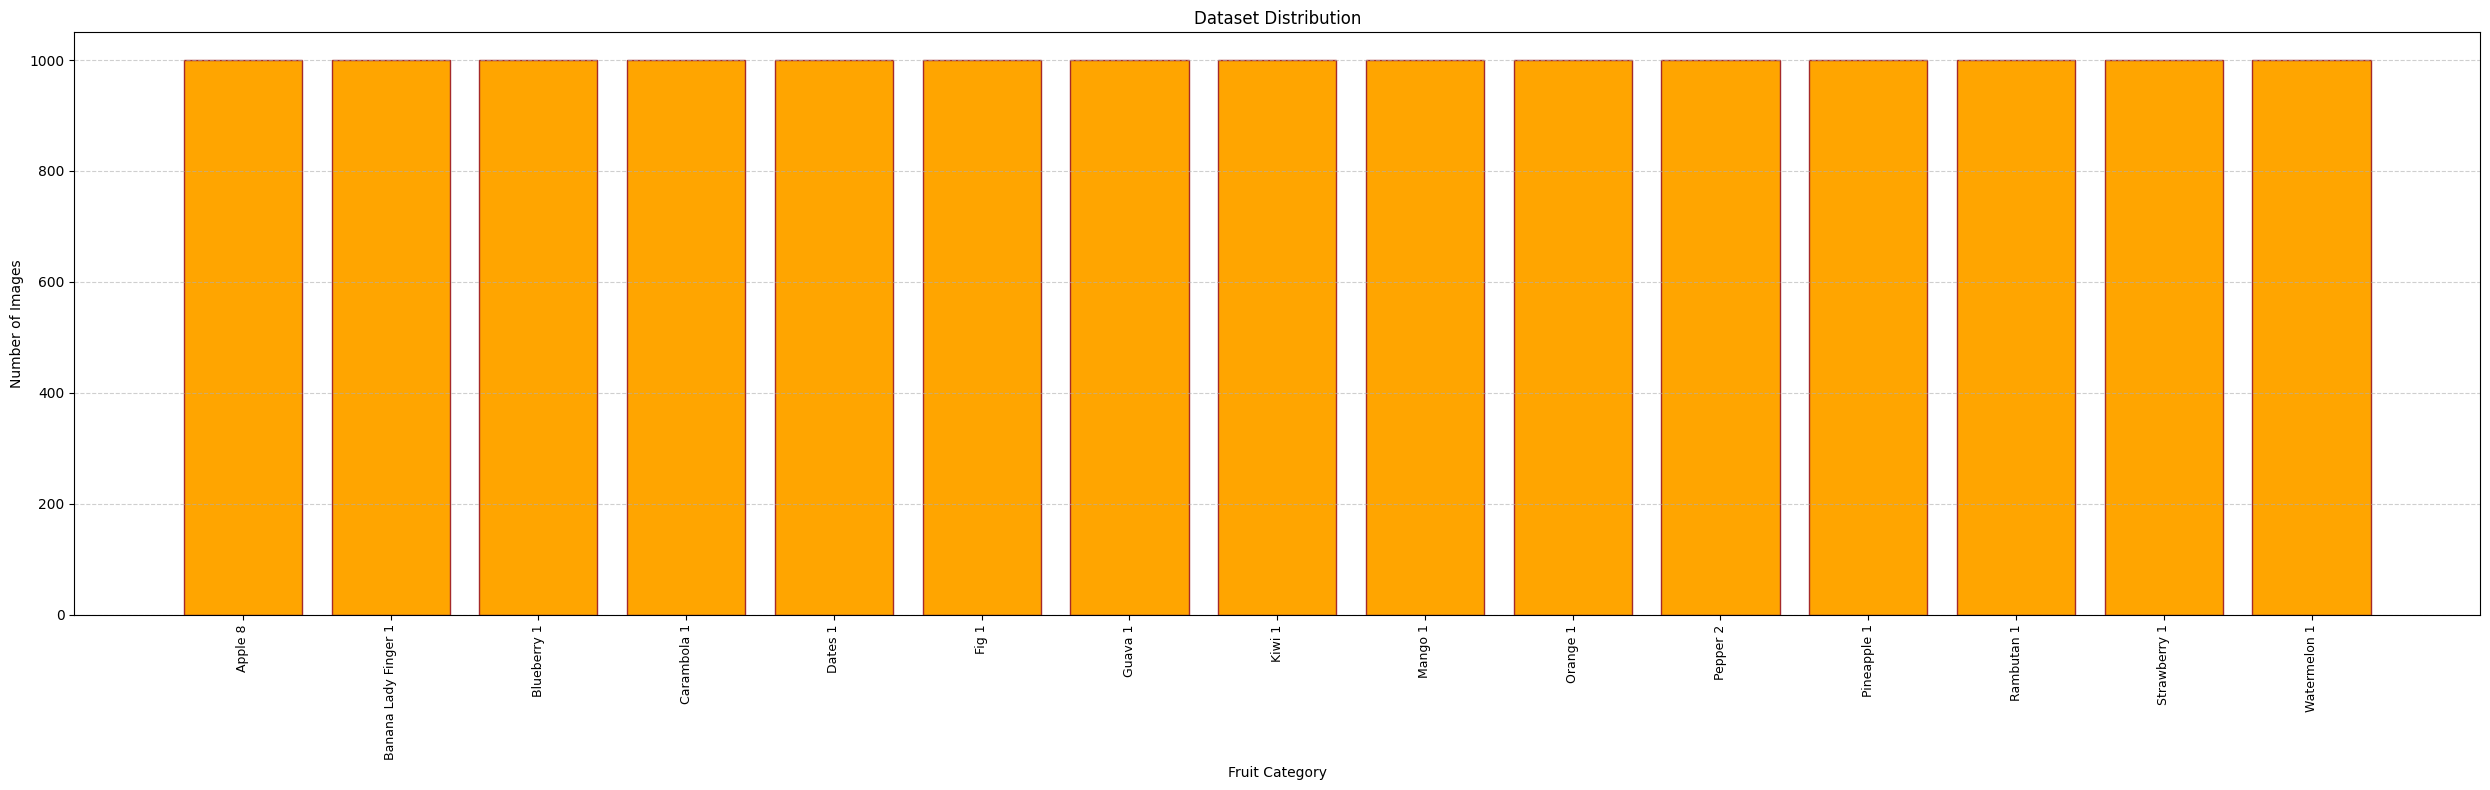

In [10]:
class_names = []
image_counts = []

for item in os.listdir(train_dir):
    item_path = os.path.join(train_dir, item)
    if os.path.isdir(item_path):
        class_names.append(item)
        image_counts.append(len(os.listdir(item_path)))

# Sort both lists together using a manual approach
paired = []
for i in range(len(class_names)):
    paired.append((class_names[i], image_counts[i]))

paired.sort()

# Create new sorted lists
sorted_names = []
sorted_counts = []
for name, count in paired:
    sorted_names.append(name)
    sorted_counts.append(count)

# visualise

plt.figure(figsize=(25, 8))
plt.bar(class_names, image_counts, color='orange', edgecolor='brown')
plt.xticks(rotation=90, fontsize=9)
plt.xlabel('Fruit Category')
plt.ylabel('Number of Images')
plt.title('Dataset Distribution')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  subset='training',
  validation_split=VALIDATION_SPLIT,
  seed=SEED,
  label_mode='int' # Multiclass classification
)
# Found class names
print(train_ds.class_names)

Found 15000 files belonging to 15 classes.
Using 12000 files for training.
['Apple 8', 'Banana Lady Finger 1', 'Blueberry 1', 'Carambola 1', 'Dates 1', 'Fig 1', 'Guava 1', 'Kiwi 1', 'Mango 1', 'Orange 1', 'Pepper 2', 'Pineapple 1', 'Rambutan 1', 'Strawberry 1', 'Watermelon 1']


In [12]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 15000 files belonging to 15 classes.
Using 3000 files for validation.


In [13]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 2557 files belonging to 15 classes.


CNN baseline model with adam

In [69]:
def build_baseline_model():
    model = tf.keras.Sequential([
        layers.Rescaling(1./255, input_shape=(100, 100, 3)),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128, activation='relu'),
        layers.Dense(15, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model1 = build_baseline_model()

In [70]:
results = []
histories = []


In [71]:
import time


def train_and_test(model, name):
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,  
        restore_best_weights=True,
        verbose=1
    )

    print(f"\n🔹 Training: {name}")
    
    start_time = time.time()   
    
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[early_stop],
        verbose=1
    )
    
    end_time = time.time()     
    training_time = end_time - start_time
    
    best_val_acc = max(history.history['val_accuracy'])
    best_val_loss = min(history.history['val_loss'])
    
    histories.append((name, history))
    
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    results.append({
        "name": name,
        "val_acc": best_val_acc,
        "val_loss": best_val_loss,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "training_time_sec": training_time
    })
    
    print(f"{name} done | Val Acc: {best_val_acc:.4f} | Test Acc: {test_acc:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")
    
    return history

In [72]:
cnn_history = train_and_test(model1, "CNN")


🔹 Training: CNN
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9412 - loss: 0.2087 - val_accuracy: 0.9950 - val_loss: 0.0163
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.9977 - loss: 0.0082 - val_accuracy: 0.9997 - val_loss: 6.5219e-04
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 1.0000 - loss: 1.0833e-04 - val_accuracy: 1.0000 - val_loss: 3.1402e-04
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 1.0000 - loss: 4.1796e-05 - val_accuracy: 1.0000 - val_loss: 2.0593e-04
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 1.0000 - loss: 2.0164e-05 - val_accuracy: 1.0000 - val_loss: 1.5338e-04
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 1.0000 - loss: 9.7938e-06 - val_accuracy: 1.0000 - val_loss: 1.4732e-04
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 1.0000 - loss: 4.7572e-06 - val_accuracy: 1.0000 - val_loss: 8.8926e-05
Epoch 8/20
375/375 ━━━━━━━━━━

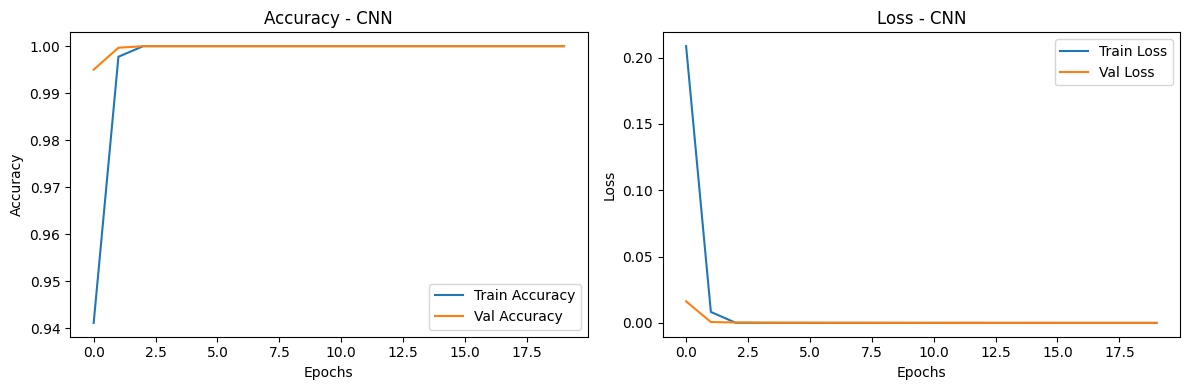

In [73]:
import matplotlib.pyplot as plt

def plot_history_side_by_side(histories, index=0):

    if index >= len(histories):
        print(f"Invalid index. histories contains only {len(histories)} items.")
        return

    name, history = histories[index]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(history.history['accuracy'], label='Train Accuracy')
    ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    ax[0].set_title(f'Accuracy - {name}')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()

    ax[1].plot(history.history['loss'], label='Train Loss')
    ax[1].plot(history.history['val_loss'], label='Val Loss')
    ax[1].set_title(f'Loss - {name}')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Loss')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_history_side_by_side(histories, index=0)

In [74]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_and_metrics(model, name, class_names):
    from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

    y_true, y_pred = [], []

    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))

        if len(labels.shape) > 1:
            y_true.extend(np.argmax(labels.numpy(), axis=1))
        else:
            y_true.extend(labels.numpy().astype(int))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall    = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1        = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

    cm_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, cm_sum, where=cm_sum != 0)

    n = len(class_names)

    fig, ax = plt.subplots(figsize=(max(10, n * 0.8), max(8, n * 0.7)))

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.4, linecolor="lightgrey",
        ax=ax
    )

    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

C:\Users\Nitro\AppData\Local\Temp\ipykernel_25880\2895354583.py:30: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, cm_sum, where=cm_sum != 0)


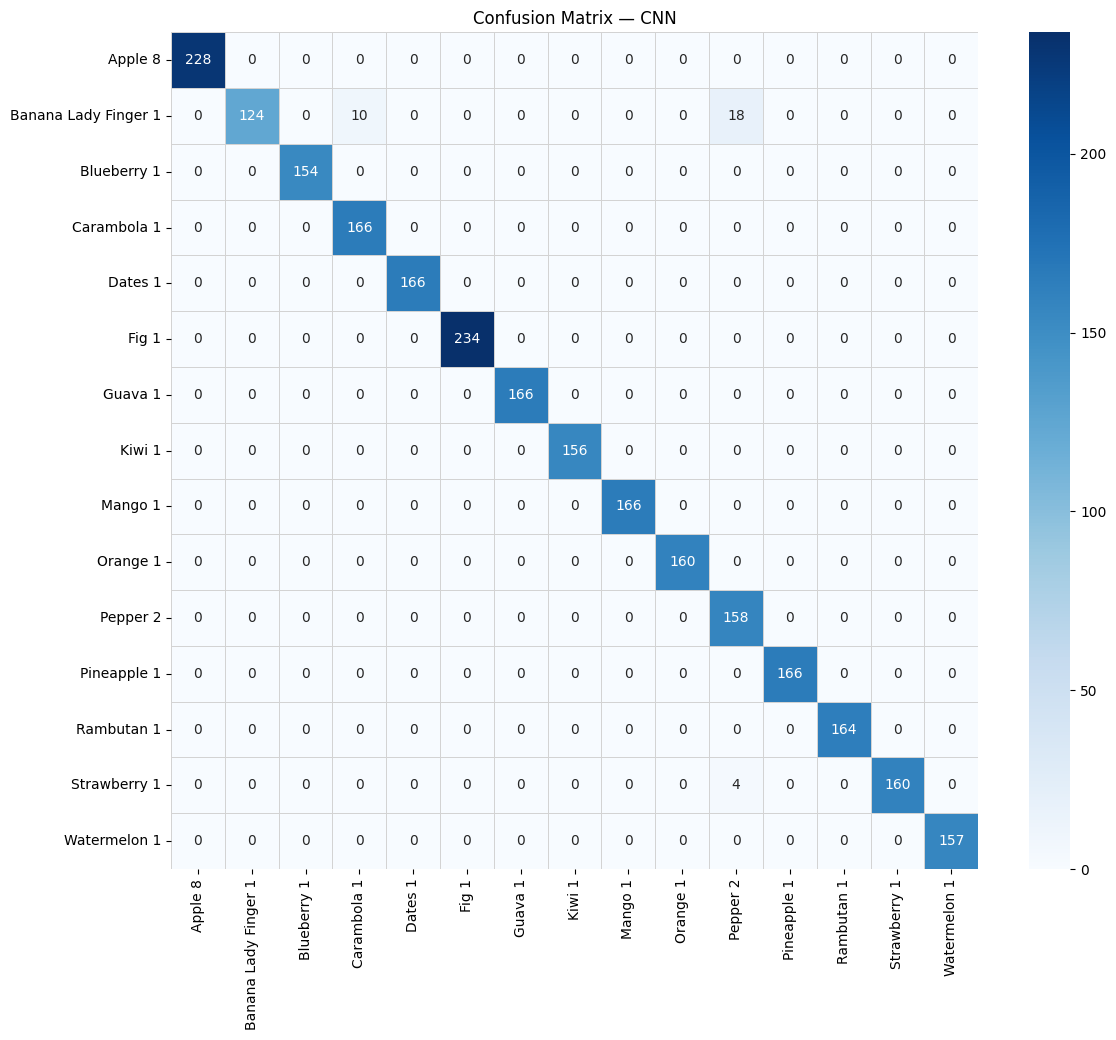

Accuracy  : 0.9875
Precision : 0.9888
Recall    : 0.9875
F1 Score  : 0.9873


In [75]:
plot_confusion_and_metrics(model1, "CNN", class_names)

In [76]:
import numpy as np
import matplotlib.pyplot as plt

def show_random_predictions(model, test_ds, class_names, num_images=9):

    image_batch, label_batch = next(iter(test_ds))

    # shuffle indices so it's random each run
    indices = np.random.choice(len(image_batch), num_images, replace=False)

    plt.figure(figsize=(15, 10))

    for i, idx in enumerate(indices):

        img = image_batch[idx]
        true_label = class_names[label_batch[idx].numpy()]

        # prediction
        pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_class = class_names[np.argmax(pred)]
        confidence = np.max(pred) * 100

        color = "green" if true_label == pred_class else "red"

        plt.subplot(3, 3, i + 1)
        plt.imshow(img.numpy().astype("uint8"))
        plt.axis("off")

        plt.title(
            f"Act: {true_label}\nPred: {pred_class} ({confidence:.1f}%)",
            color=color,
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

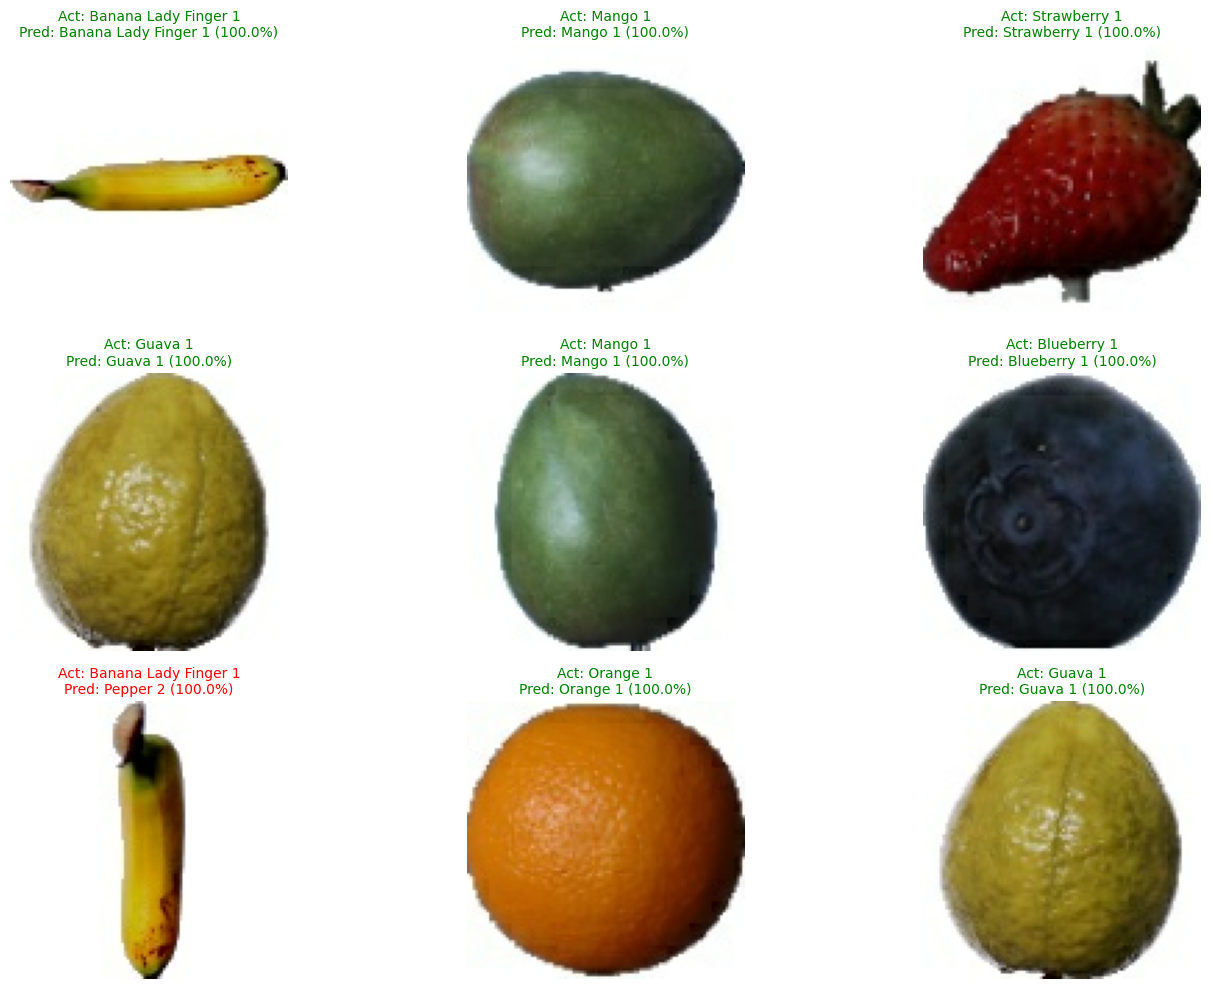

In [77]:
show_random_predictions(model1, test_ds, class_names, num_images=9)

basline cnn with sgd

In [24]:
# from tensorflow.keras.optimizers import SGD

# def build_sgd_model():
#     model = tf.keras.Sequential([
#         layers.Rescaling(1./255, input_shape=(100, 100, 3)),

#         layers.Conv2D(32, (3,3), activation='relu'),
#         layers.MaxPooling2D(),

#         layers.Conv2D(64, (3,3), activation='relu'),
#         layers.MaxPooling2D(),

#         layers.Flatten(),

#         layers.Dense(128, activation='relu'),
#         layers.Dense(15, activation='softmax')
#     ])

#     model.compile(
#         optimizer=SGD(learning_rate=0.01),
#         loss='sparse_categorical_crossentropy',
#         metrics=['accuracy']
#     )

#     return model

# model2 = build_sgd_model()
# cnn_sgd_history = train_and_test(model2, "CNN + SGD")

In [25]:
# plot_history_side_by_side(histories, index=1)

In [26]:
# show_random_predictions(model2, test_ds, class_names, num_images=9)

## Deeper Model: Part 2

Deeper model with adam

In [78]:
def get_augmentation():
    return tf.keras.Sequential([
        layers.RandomZoom(height_factor=(-0.3, 0.0), width_factor=(-0.3, 0.0)),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
    ])

In [80]:
from tensorflow.keras import models, layers
data_augmentation = get_augmentation()

def build_deeper_cnn(IMG_HEIGHT, IMG_WIDTH, num_classes, data_augmentation):
    
    model = models.Sequential([
        # Input
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # Data augmentation (training only)
        data_augmentation,

        # Normalize
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')
    ])

    return model

In [83]:
model3 = build_deeper_cnn(IMG_HEIGHT, IMG_WIDTH, len(class_names), data_augmentation)

In [84]:
model3.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [85]:
deeper_cnn_adam_history= train_and_test(model3, "Deeper CNN + Regularisation + BN + Dropout")


🔹 Training: Deeper CNN + Regularisation + BN + Dropout
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 163s 420ms/step - accuracy: 0.7492 - loss: 0.7976 - val_accuracy: 0.2567 - val_loss: 7.0866
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 160s 427ms/step - accuracy: 0.9130 - loss: 0.2829 - val_accuracy: 0.8387 - val_loss: 0.7495
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 155s 413ms/step - accuracy: 0.9467 - loss: 0.1877 - val_accuracy: 0.8697 - val_loss: 0.4194
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 160s 427ms/step - accuracy: 0.9675 - loss: 0.1185 - val_accuracy: 0.9887 - val_loss: 0.0471
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 150s 399ms/step - accuracy: 0.9712 - loss: 0.1092 - val_accuracy: 0.9967 - val_loss: 0.0113
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 145s 388ms/step - accuracy: 0.9759 - loss: 0.0895 - val_accuracy: 0.9680 - val_loss: 0.1055
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 913s 2s/step - accuracy: 0.9765 - loss: 0.0875 - val_accuracy: 0.7740 - val_loss: 1.3004
Epoch 8/20
375/375 ━━━━

In [86]:
for i, (name, _) in enumerate(histories):
    print(i, name)

0 CNN
1 Deeper CNN + Regularisation + BN + Dropout


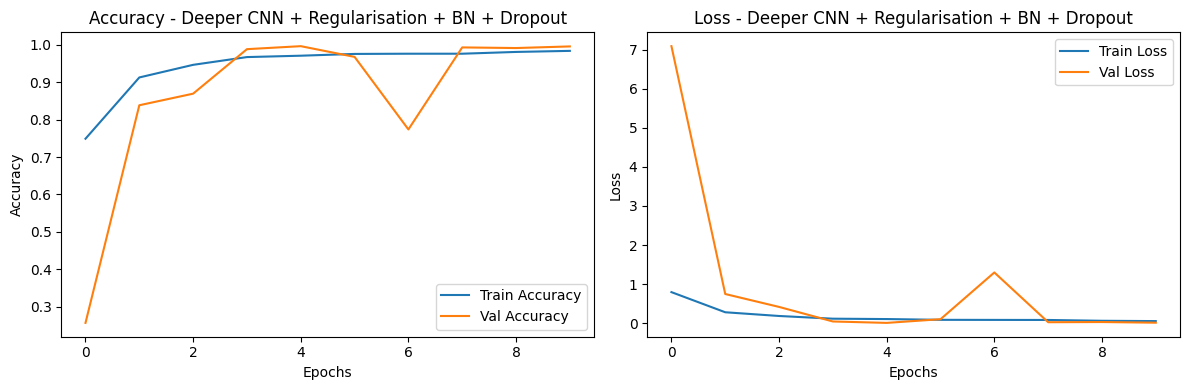

In [87]:
plot_history_side_by_side(histories, index=1)

C:\Users\Nitro\AppData\Local\Temp\ipykernel_25880\2895354583.py:30: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, cm_sum, where=cm_sum != 0)


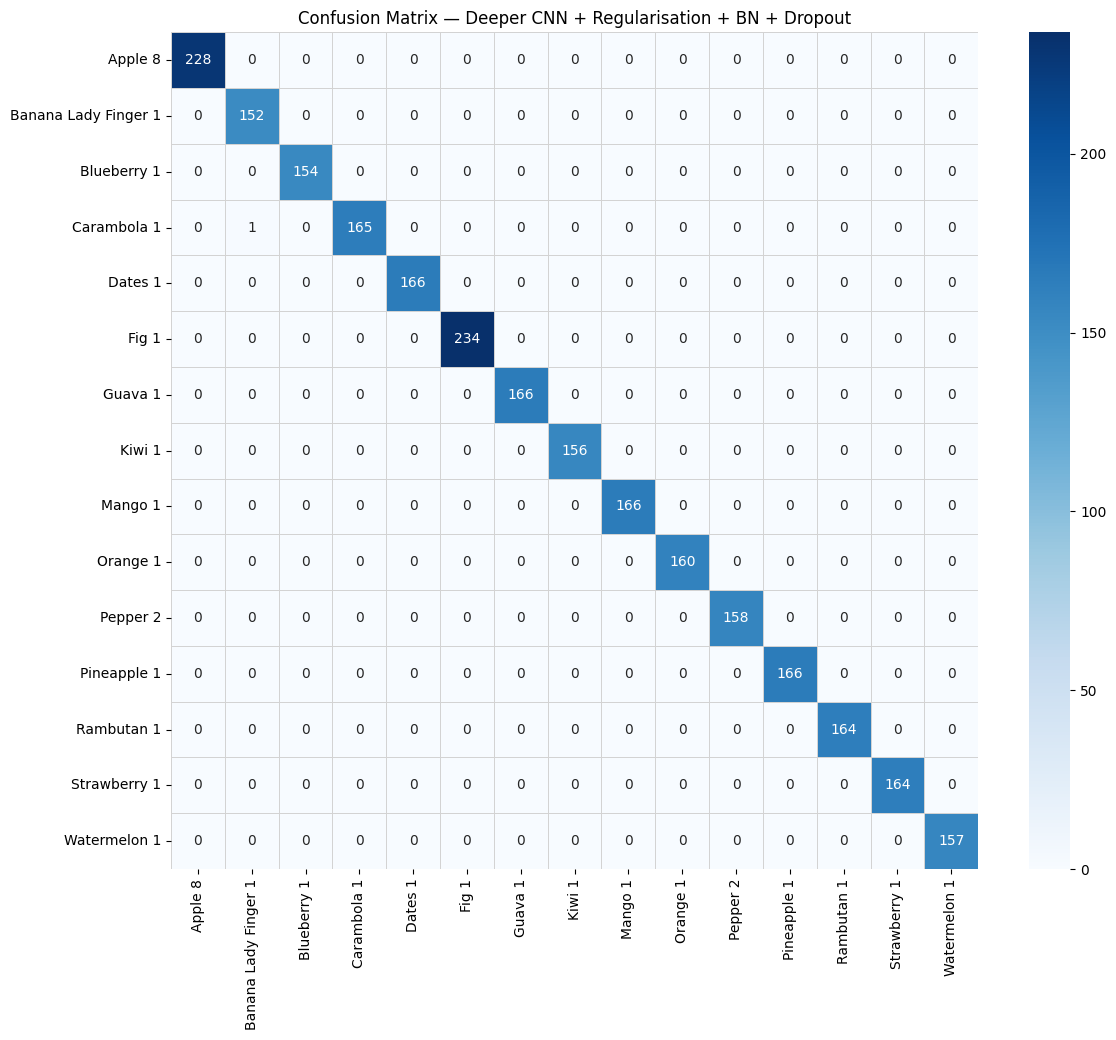

Accuracy  : 0.9996
Precision : 0.9996
Recall    : 0.9996
F1 Score  : 0.9996


In [88]:
plot_confusion_and_metrics(model3, "Deeper CNN + Regularisation + BN + Dropout", class_names)

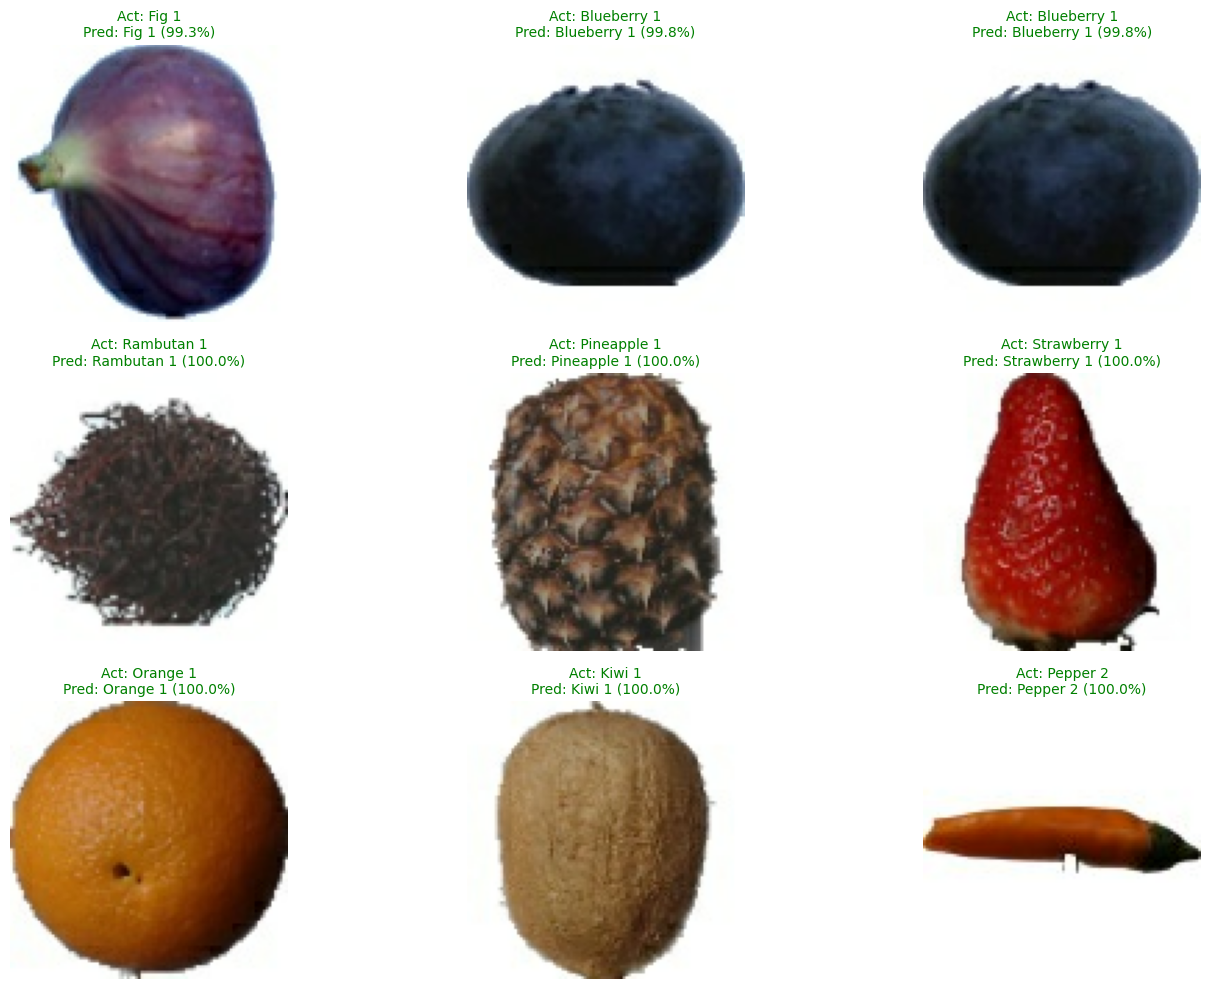

In [89]:
show_random_predictions(model3, test_ds, class_names, num_images=9)

deeper cnn model with sgd

In [90]:
model4= build_deeper_cnn(IMG_HEIGHT, IMG_WIDTH, len(class_names), data_augmentation)
model4.compile(
    optimizer=SGD(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [91]:
deeper_cnn_sgd_history = train_and_test(model4, "Deeper CNN + Regularisation + BN + Dropout + SGD")


🔹 Training: Deeper CNN + Regularisation + BN + Dropout + SGD
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 140s 369ms/step - accuracy: 0.2806 - loss: 2.4356 - val_accuracy: 0.0807 - val_loss: 3.4868
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 159s 424ms/step - accuracy: 0.6157 - loss: 1.1558 - val_accuracy: 0.5087 - val_loss: 1.4961
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 162s 431ms/step - accuracy: 0.7326 - loss: 0.8045 - val_accuracy: 0.5567 - val_loss: 1.3768
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 161s 430ms/step - accuracy: 0.7967 - loss: 0.6284 - val_accuracy: 0.5827 - val_loss: 1.2452
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 157s 419ms/step - accuracy: 0.8400 - loss: 0.5079 - val_accuracy: 0.6157 - val_loss: 1.1305
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 147s 391ms/step - accuracy: 0.8725 - loss: 0.4177 - val_accuracy: 0.6937 - val_loss: 0.9477
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 143s 380ms/step - accuracy: 0.8939 - loss: 0.3529 - val_accuracy: 0.6930 - val_loss: 0.9514
Epoch 8/20
375

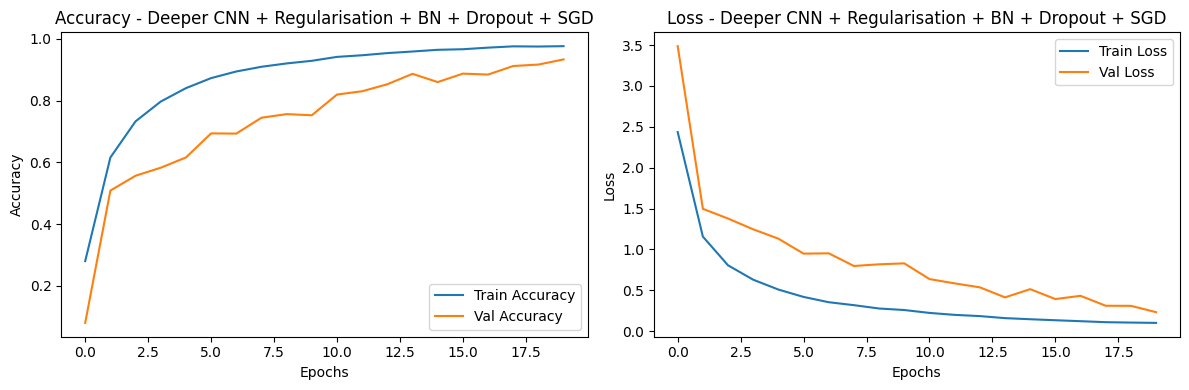

In [94]:
plot_history_side_by_side(histories, index=2)

C:\Users\Nitro\AppData\Local\Temp\ipykernel_25880\2895354583.py:30: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, cm_sum, where=cm_sum != 0)


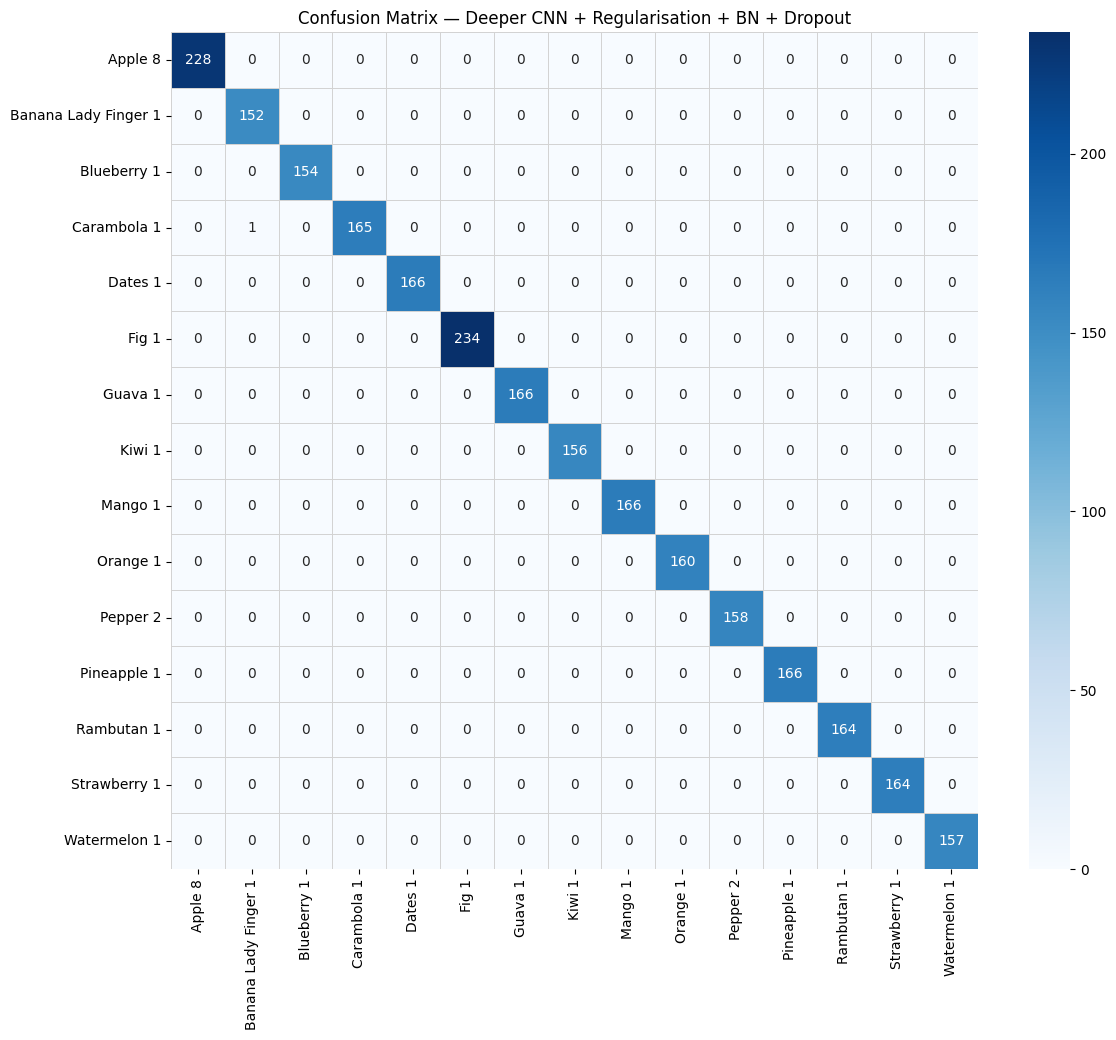

Accuracy  : 0.9996
Precision : 0.9996
Recall    : 0.9996
F1 Score  : 0.9996


In [95]:
plot_confusion_and_metrics(model3, "Deeper CNN + Regularisation + BN + Dropout", class_names)

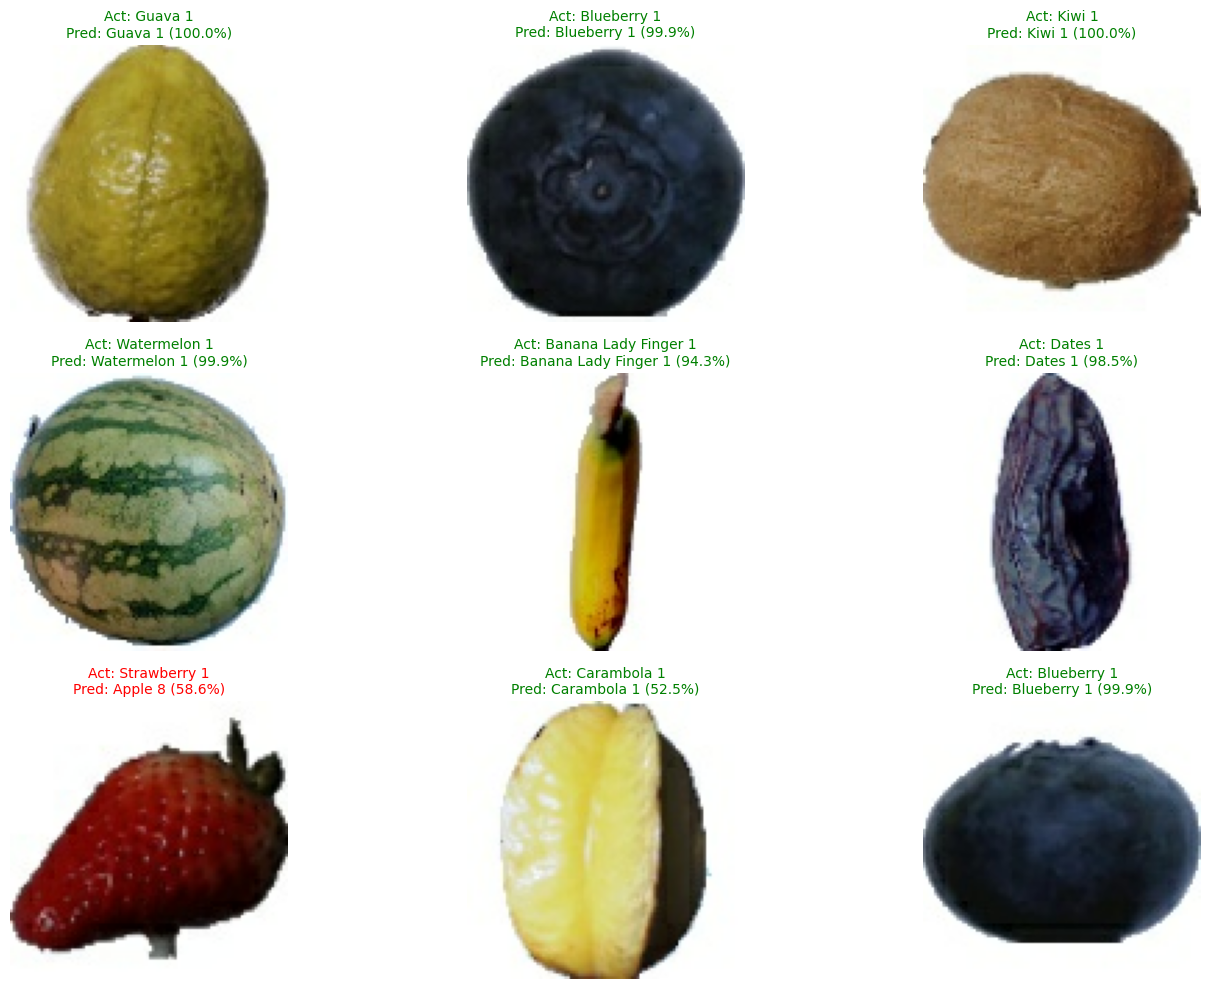

In [96]:
show_random_predictions(model4, test_ds, class_names, num_images=9)

# Part-3: Transfer Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

print("All imports successful!")

All imports successful!


In [ ]:
num_classes = len(train_ds.class_names)

#load VGG16 without top classification layer
base_model = VGG16(
    weights='imagenet',         # Use pretrained ImageNet weights
    include_top=False,          # Remove VGG16's original 1000-class output
    input_shape=(224, 224, 3)   # VGG16 expects 224x224
)

In [ ]:
# Freeze the base model (Feature Extraction phase)
base_model.trainable = False

print(f"Total layers in VGG16: {len(base_model.layers)}")
print(f"Trainable layers: {len(base_model.trainable_variables)}")

Total layers in VGG16: 19
Trainable layers: 0


In [ ]:
# ── Step 2: Build using Functional API ───────────────────────────────────────
inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Augmentation FIRST (before resizing, at original image size)
x = data_augmentation(inputs)

# THEN resize to VGG16 expected size
x = layers.Resizing(224, 224)(x)

# VGG16 preprocessing
x = preprocess_input(x)

# VGG16 base
x = base_model(x, training=False)

# Classification head
x = layers.Flatten()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

vgg_model = models.Model(inputs, outputs, name='VGG16_Transfer')
vgg_model.summary()

Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 100, 100,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 224, 224,  │          0 │ sequential[0][0]  │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ resizing[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ resizing[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │ 12,845,568 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 15)        │      3,855 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,697,487 (105.66 MB)

 Trainable params: 12,981,775 (49.52 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [ ]:
# ── Step 3: Compile and Train Phase 1 (Feature Extraction) ───────────────────
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
]

In [ ]:
print("\nPhase 1: Feature Extraction ")
history_vgg_fe = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

# ── Step 4: Fine-Tuning Phase ────────────────────────────────────────────────
print("\nPhase 2: Fine-Tuning (last 4 layers) ")
base_model.trainable = True

# Freeze everything except last 4 layers
for layer in base_model.layers[:-4]:
    layer.trainable = False


── Phase 1: Feature Extraction ──────────────────────────────────────────
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 533s 1s/step - accuracy: 0.9807 - loss: 0.0719 - val_accuracy: 0.9983 - val_loss: 0.0281 - learning_rate: 0.0010
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 612s 2s/step - accuracy: 0.9985 - loss: 0.0057 - val_accuracy: 0.9983 - val_loss: 0.2368 - learning_rate: 0.0010
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 710s 2s/step - accuracy: 0.9980 - loss: 0.0076 - val_accuracy: 0.9980 - val_loss: 0.1130 - learning_rate: 0.0010
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 640s 2s/step - accuracy: 0.9950 - loss: 0.0182 - val_accuracy: 1.0000 - val_loss: 4.9537e-06 - learning_rate: 0.0010
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 591s 2s/step - accuracy: 0.9990 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 1.8808e-04 - learning_rate: 0.0010

── Phase 2: Fine-Tuning (last 4 layers) ─────────────────────────────────


In [ ]:

# Must recompile after changing trainability
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg_ft = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1266s 3s/step - accuracy: 0.9998 - loss: 4.1642e-04 - val_accuracy: 0.9993 - val_loss: 0.0183 - learning_rate: 1.0000e-05
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1188s 3s/step - accuracy: 0.9998 - loss: 7.1143e-04 - val_accuracy: 0.9993 - val_loss: 0.0288 - learning_rate: 1.0000e-05
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 598s 2s/step - accuracy: 0.9998 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 5.8733e-07 - learning_rate: 1.0000e-05
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 669s 2s/step - accuracy: 0.9998 - loss: 5.6412e-04 - val_accuracy: 0.9993 - val_loss: 0.0122 - learning_rate: 2.0000e-06
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 707s 2s/step - accuracy: 0.9999 - loss: 4.7749e-04 - val_accuracy: 0.9997 - val_loss: 0.0127 - learning_rate: 2.0000e-06


In [ ]:
plot_history_side_by_side(histories, index=4)

In [ ]:
plot_confusion_and_metrics(vgg_model, "VGG Model", class_names)

In [ ]:
show_random_predictions(vgg_model, test_ds, class_names, num_images=9)

94/94 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.9993 - loss: 0.0183

VGG16 Transfer Learning Accuracy: 0.9993


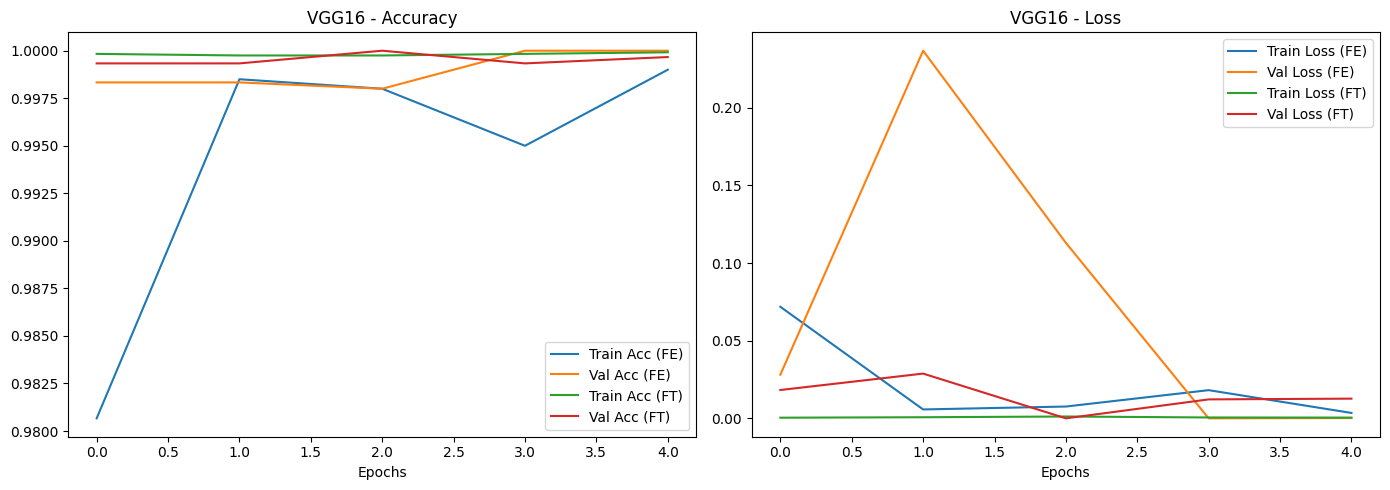

In [ ]:
# ── Step 5: Evaluate ──────────────────────────────────────────────────────────
loss, accuracy = vgg_model.evaluate(val_ds)
print(f"\nVGG16 Transfer Learning Accuracy: {accuracy:.4f}")

# ── Step 6: Plot ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_vgg_fe.history['accuracy'], label='Train Acc (FE)')
axes[0].plot(history_vgg_fe.history['val_accuracy'], label='Val Acc (FE)')
axes[0].plot(history_vgg_ft.history['accuracy'], label='Train Acc (FT)')
axes[0].plot(history_vgg_ft.history['val_accuracy'], label='Val Acc (FT)')
axes[0].set_title('VGG16 - Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].legend()


axes[1].plot(history_vgg_fe.history['loss'], label='Train Loss (FE)')
axes[1].plot(history_vgg_fe.history['val_loss'], label='Val Loss (FE)')
axes[1].plot(history_vgg_ft.history['loss'], label='Train Loss (FT)')
axes[1].plot(history_vgg_ft.history['val_loss'], label='Val Loss (FT)')
axes[1].set_title('VGG16 - Loss')
axes[1].set_xlabel('Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:

baseline_loss, baseline_acc = model.evaluate(val_ds)
deeper_loss, deeper_acc = deeper_model.evaluate(val_ds)
vgg_loss, vgg_acc = vgg_model.evaluate(val_ds)

print(f"\n{'Model':<25} {'Accuracy':>10} {'Loss':>10}")
print("-" * 45)
print(f"{'Baseline CNN':<25} {baseline_acc:>10.4f} {baseline_loss:>10.4f}")
print(f"{'Deeper CNN':<25} {deeper_acc:>10.4f} {deeper_loss:>10.4f}")
print(f"{'VGG16 Transfer Learning':<25} {vgg_acc:>10.4f} {vgg_loss:>10.4f}")

NameError: name 'model' is not defined